In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
import os
import math

# Training and validation data

In [ ]:
df_val = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
df_val = df_val.rename(columns={'Epitope' : 'model'})
df_val = df_val[df_val['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]

topir = 'TCR_motif_atlas'

final_epitopes = []
for model, val_group in df_val.groupby('model'):
    if model not in ["A0201_LLWNGPMAV", "A0201_GILGFVFTL"]:
        continue
    if not (model.startswith('A') or model.startswith('B')):
        continue
    if len(val_group):
        continue
    os.makedirs(model, exist_ok=True)
    val_group.to_csv(f'{topir}/{model}/validation.csv', index=False)
    final_epitopes.append(model)

with open(f'{topir}/epitopes.txt', 'w') as f:
    f.write('\n'.join(final_epitopes))

print(f'{len(final_epitopes)} epitopes written to epitopes.txt')

2 epitopes written to epitopes.txt


# AF3 scores

step0 A0201_GILGFVFTL 0.5 158
step0 A0201_GILGFVFTL 0.8 1
step0 A0201_LLWNGPMAV 0.5 184
step0 A0201_LLWNGPMAV 0.8 2
step1 A0201_GILGFVFTL 0.5 53
step1 A0201_GILGFVFTL 0.8 1
step1 A0201_LLWNGPMAV 0.5 105
step1 A0201_LLWNGPMAV 0.8 1


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_13107/898446469.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/model_alpha_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_13107/898446469.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/model_alpha_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_13107/898446469.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/model_alpha_o

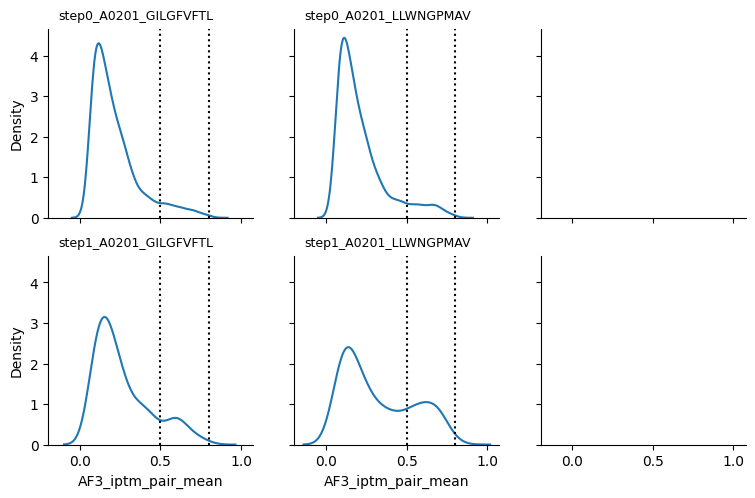

In [12]:
fig, axes = plt.subplots(2,3, figsize=(3*3,2.7*2), sharex=True, sharey=True)

steps = ['step0', 'step1']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

for cnt1, step in enumerate(steps):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]
        df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/model_alpha_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        
        sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
        sns.despine()
        ax.text(0.05, 1.05, f'{step}_{peptide}', transform=ax.transAxes, fontsize=9)
        ax.axvline(x=0.5, color='black', linestyle=':')
        ax.axvline(x=0.8, color='black', linestyle=':')

        print(step, peptide, 0.5, len(df[df['AF3_iptm_pair_mean']>0.5]))
        print(step, peptide, 0.8, len(df[df['AF3_iptm_pair_mean']>0.8]))

# AUC

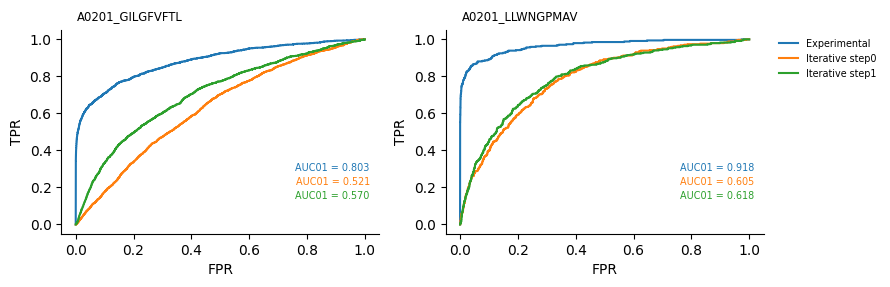

In [17]:
epitopes = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
steps = ['step0', 'step1']

fig, axes = plt.subplots(1, len(epitopes), figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes,
            va='top', ha='left', fontsize='small')

    # --- Experimental curve ---
    df = pd.read_csv(
        f'../260512_TEMPO_motif_builder_test/{epitope}/TEMPO_train_exp.csv'
    )
    y_true, y_scores = df['Label'].values, df['score'].values
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
    line, = ax.plot(fpr, tpr, label='Experimental')
    ax.text(0.97, 0.3, f"AUC01 = {auc01:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize='x-small', color=line.get_color())

    # --- One curve per step ---
    for i, s in enumerate(steps):
        df = pd.read_csv(
            f'TCR_motif_atlas/{epitope}/{s}/validation/validation_pred.csv'
        )
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
        line, = ax.plot(fpr, tpr, label=f'Iterative {s}')
        ax.text(0.97, 0.23 - i * 0.07, f"AUC01 = {auc01:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()
